# Topic #3. Symbolic Mathematics

Symbolic Mathematics (also known as Computer Algebra).

Unlike traditional numerical mathematics (where you plug in numbers and get a decimal answer), symbolic mathematics works with formulas and variables the way mathematicians do by hand.

## Main difference from numerical mathematics

| **Numerical Mathematics** | **Symbolical Mathematics** |
|---------------------------|---------------------------|
| Input: `2 + 3` | Input: `a + b` |
| Output: `5` | Output: `a + b` (unchanged) |

| **Numerical Mathematics** | **Symbolical Mathematics** |
|---------------------------|---------------------------|
| Input: `sqrt(9)` | Input: `diff(x^3, x)` |
| Output: `3.0` | Output: `3*x^2` (derivative) |

| **Numerical Mathematics** | **Symbolical Mathematics** |
|---------------------------|---------------------------|
| **Result — a number.** | **Result — an expression (formula).** |

The main goal of symbolic mathematics is to obtain an **exact analytical solution**, not an approximate value.

## Basic Concepts

In symbolic mathematics, all objects are divided into three types:

### Atoms (Leaves)

- **Variables**: `x`, `y`, `a`.
- **Constants**: numbers (`Pi`, `e`, `1/3`).
*Important: `1/3` remains a fraction and does not become `0.333...`.*
- **Functions**: `sin`, `log`, `exp`.

---

### Expressions (Trees)

Any formula is represented as a **parse tree**.
For example, the expression `3*x + sin(y)` is stored in memory as the structure:

```text
        +
       / \
      *   sin
     / \    |
    3   x   y
```

## SymPy Library

In Python, the primary library of choice for symbolic mathematics is the **SymPy** library.

Goal: Learn the basic functions of the **SymPy** library and understand its fundamental operating principles.

### Installation

To install the library, use the package manager **pip**. In the terminal, type:
```shell
python -m pip install sympy
```

### Symbolic Expressions

The **SymPy** library is used for symbolic computations. It allows you to work with symbolic expressions, perform various transformations on them, find derivatives, take integrals, and solve equations.

In [1]:
from sympy import symbols

In [2]:
# Create symbols
x, y = symbols("x y")

# Write the expression
expr = x + y * 3

# Print the result
print(expr) # x + 3*y

x + 3*y


Here `x` and `y` are symbols, not numbers (not variables like `double` or `int`), so Python does not evaluate the expression, but simply prints it symbolically.

#### Substituting Values

To substitute numbers into an expression, use the `expr.subs(old, new)` method.
- `old` is the character, number, or expression being replaced.
- `new` is the new value or expression being substituted.

You can pass a dictionary to substitute multiple values ​​at once: `expr.subs({old1: new1, old2: new2, ...})`.

In [3]:
value = expr.subs({x: 2, y: 5})
print(value)

17


#### Simplifying Expressions

In SymPy, expressions are often simplified automatically when created or printed, especially if they involve arithmetic operations with numbers.
For example, the expression $$8-3\cdot \left(\frac{1}{3}+0.2\right)-10+x,$$ represented as

In [4]:
expr = 8 - 3*(1 / 3 + 0.2) - 10 + x

will be automatically simplified to:

In [5]:
print(expr)

x - 3.6


If you want to leave the expression **unchanged**, you can use the `UnevaluatedExpr` function:

In [6]:
from sympy import UnevaluatedExpr as ue

x, y = symbols("x y")
expr = ue(8) - 3*(ue(1) / ue(3) + 0.2) - ue(10) + x

print(expr)

x - 3*(0.2 + 1*3**(-1)) + 8 - 10


To simplify the expression, there is a function `simplify()`:

In [7]:
from sympy import simplify
simplify(expr)

x - 3.6

There are two methods for converting the result of an expression to a floating-point value: `N()` and `evalf()`. They are almost identical, but there is a slight difference:

- `evalf()` is a method of the object that stores the expression.
`evalf()` is called on a specific expression and evaluates its numerical value:

In [8]:
import sympy as sp

x = sp.Symbol("x")
expr = sp.sin(x) + sp.exp(x)

print(expr.evalf(subs={x: 1}))

3.55975281326694


- `sp.N()` — works the same way, but it's a global function, not an object method:

In [9]:
print(sp.N(expr, subs={x: 1}))

3.55975281326694


It is useful if you need to calculate something without calling the `evalf()` method.

#### Expanding Parentheses

To expand parentheses in symbolic expressions, use the `expand()` method.

In [10]:
from sympy import symbols, sin, cos, expand

x, y = symbols('x y')

expr = ((x + 15)**3) / ((x - 2)**4)
expanded_expr = expr.expand(trig=True)

print("Original expression:", expr)
print("Expanded expression:", expanded_expr)

Original expression: (x + 15)**3/(x - 2)**4
Expanded expression: x**3/(x**4 - 8*x**3 + 24*x**2 - 32*x + 16) + 45*x**2/(x**4 - 8*x**3 + 24*x**2 - 32*x + 16) + 675*x/(x**4 - 8*x**3 + 24*x**2 - 32*x + 16) + 3375/(x**4 - 8*x**3 + 24*x**2 - 32*x + 16)


#### Some parameters of the `expand()` method

- `basic=True` (default).
Expands standard parentheses in expressions.
- `power_exp=True`.
Expands the power of a power.
- `power_base=True`.
Expands powers with the same base.
- `mul=True`
Expands products.
- `log=True`
Uses logarithmic properties.
- `trig=True`
Expands trigonometric expressions.
- `complex=True`
Separates an expression into its real and imaginary parts.

In [11]:
from sympy import I
expand((1 + I) ** 2, complex=True)  

2*I

- Example with several parameters:

In [12]:
expand((x*y)**3 + sin(x + y), power_base=True, trig=True)

x**3*y**3 + sin(x)*cos(y) + sin(y)*cos(x)

In addition, you can combine parameters in `expand()`, specifying only the ones you need.

In [13]:
expand((x*y)**3 + sin(x + y), power_base=True, trig=True)

x**3*y**3 + sin(x)*cos(y) + sin(y)*cos(x)

#### Derivation of expressions

For example we have some expression

In [14]:
import sympy as sp

In [15]:
a = sp.symbols("a", real = True)
x = (sp.exp(-abs(a)**1.2) + sp.sin(a**4)) / a

It can be printed to the console using the `pprint()` function.
This is a function from the SymPy library that formats and elegantly prints mathematical expressions to the console.
It makes the output more readable by adding fractions, exponents, and other symbols in a convenient format.

In [16]:
sp.pprint(x)

               1.2
   ⎛ 4⎞    -│a│   
sin⎝a ⎠ + ℯ       
──────────────────
        a         


#### Translation symbols expressions to $\LaTeX$

You can convert symbol expression to $\LaTeX$ with `latex()` function.

In [17]:
from sympy import latex
latex_expr = latex(x)
print(latex_expr)

\frac{\sin{\left(a^{4} \right)} + e^{- \left|{a}\right|^{1.2}}}{a}


Next, we display the result using Markdown: $$\frac{\sin{\left(a^{4} \right)} + e^{- \left|{a}\right|^{1.2}}}{a}$$

In addition, JupyterLab can output expressions to $\LaTeX$ automatically.

In [18]:
x

(sin(a**4) + exp(-Abs(a)**1.2))/a

### Symbolic Functions, Lambda Expressions

Symbolic expressions can be "wrapped" in lambda expressions to improve code readability and simplify interaction. Here's an example:

In [19]:
import sympy as sp

In [20]:
x = sp.symbols("x")

expr = x - x**3 / 10 + x**6 / 120
y = sp.lambdify(x, expr)

point = sp.pi/6
result = y(point)
sp.pprint(result)

                        3                        6   π
- 0.000462962962962963⋅π  + 1.78612254229538e-7⋅π  + ─
                                                     6


In [21]:
print(result.evalf())

0.509415733766994


The `lambdify()` function allows you to convert SymPy expressions into regular Python functions.
However, if you don't specify the correct module, errors may occur, such as:

In [22]:
import sympy as sp

x = sp.symbols("x")
y = sp.lambdify(x, sp.sin(x)) # Uses NumPy by default

print(y(sp.pi/6))

TypeError: loop of ufunc does not support argument 0 of type Mul which has no callable sin method

We specify `modules="sympy"` to tell the lambda function to use SymPy for calculations:

In [23]:
y = sp.lambdify(x, sp.sin(x), "sympy")
print(y(sp.pi/6))

1/2


### Derivatives

The library has the ability to find derivatives.

In [24]:
import sympy as sp

In [25]:
x = sp.symbols("x")
f = x**2 + 3*x + 2
f_prime = sp.diff(f, x)

In [26]:
f

x**2 + 3*x + 2

In [27]:
f_prime

2*x + 3

It is possible to find partial derivatives.

In [28]:
x, y = sp.symbols("x y")
f = sp.lambdify((x, y), x**2 + y**2 + 3*x*y)

# Find the partial derivative of a function with respect to x
f_prime_x = sp.diff(f(x, y), x)

# Find the partial derivative of a function with respect to y
f_prime_y = sp.diff(f(x, y), y)

print(f"Partial derivative with respect to x: {f_prime_x}")
print(f"Partial derivative with respect to y: {f_prime_y}")

Partial derivative with respect to x: 2*x + 3*y
Partial derivative with respect to y: 3*x + 2*y


### Limits

#### One-sided and two-sided limits

To find limits there is a function `limit()`.

In [29]:
from sympy import symbols, limit

x = symbols('x')
expr = (x**2 - 1) / (x - 1)

lim = limit(expr, x, 1)  # Two-sided limit as x -> 1
print(lim)

2


You can find one-sided limits by specifying the `dir="-"` or `dir="+"` parameter:

In [30]:
lim_left = limit(expr, x, 1, dir="-")  # Left (x → 1⁻)
lim_right = limit(expr, x, 1, dir="+") # Right (x → 1⁺)

#### Limits in infinity

If you need to operate with infinities, you need to include `oo`.

In [31]:
from sympy import oo

In [32]:
expr = (3*x**2 + x) / (2*x**2 - 5)

lim_inf = limit(expr, x, oo) # x → ∞
lim_neg_inf = limit(expr, x, -oo) # x → -∞

print(lim_inf) # 3/2
print(lim_neg_inf) # 3/2

3/2
3/2


##### Special cases

Let there exist a function $f(x) = \dfrac{1}{x}$ that has two limits as $x \to 0$, depending on the direction:

- Left ($x \to 0^-$): $\dfrac{1}{x} \to -\infty$.

- Right ($x \to 0^+$): $\dfrac{1}{x} \to +\infty$.

Since the left-hand and right-hand limits are not the same, there is no limit at $x = 0$.

If the limit does not exist, SymPy will return $\infty$, $-\infty$, or fail to compute.

In [33]:
expr = 1 / x
print(limit(expr, x, 0, dir='+'))  # oo
print(limit(expr, x, 0, dir='-'))  # -oo
print(limit(expr, x, 0))

oo
-oo
oo


### Integrals

In SymPy, you can calculate integrals using the `integrate()` function. Let's look at examples of its use for calculating indefinite and definite integrals.

#### Indefinite integral

In [34]:
from sympy import symbols, integrate

# Let's define a variable
x = symbols('x')

# Integral of x^2
integral = integrate(x**2, x)
integral

x**3/3

#### Definite integral

Definite integral of $x^2$ on the interval $[0, 1]$:

In [35]:
integral_definite = integrate(x**2, (x, 0, 1))
print(integral_definite)

1/3


### Equations and inequalities

#### Equations

Equations in SymPy are defined using the `Eq()` function. Let's look at an example.

In [36]:
from sympy import symbols, Eq

x, y = symbols("x y")
eq = Eq(2*x + 3, 7)
eq

Eq(2*x + 3, 7)

To solve equations there are functions `solve()`, `nsolve()`, `dsolve()`.

In [37]:
from sympy import solve
solved_eq = solve(eq, x)
solved_eq

[2]

#### Inequalities

For inequality we use functions
- `Gt()` ($>$),
- `Ge()` ($\geqslant$),
- `Lt()` ($<$),
- `Le()` ($\leqslant$).

In [38]:
x = sp.symbols("x")

# Define inequality
inequality = sp.Gt(x**2 - 4, 0) # x^2 - 4 > 0

# Solving the inequality
solution = sp.solve(inequality, x)
(solution)

((-oo < x) & (x < -2)) | ((2 < x) & (x < oo))

#### Differential equations

In [39]:
x = sp.symbols("x")
y = sp.Function("y")(x)

diff_eq = sp.Eq(y.diff(x), y)
solution = sp.dsolve(diff_eq)

print(solution)

Eq(y(x), C1*exp(x))


##### Cauchy problem

Let the initial condition be $y(0)=1$, then

In [40]:
solution_with_condition = sp.dsolve(diff_eq, ics={y.subs(x, 0): 1})

# We derive the solution taking into account the initial condition
print(solution_with_condition)

Eq(y(x), exp(x))


#### General Information

In Maple, we used the `isolate()` function to express variables, which allowed us to isolate a variable in an equation.

You can get the left-hand and right-hand sides of an equation using `.lhs` and `.rhs`:

In [41]:
from sympy import symbols, Eq, isolate

x, d = symbols("x d")
eq = Eq(x + 2*d, 5 + x**2)

left = eq.lhs   # Left-hand side of the equation
right = eq.rhs  # Right-hand side of the equation

print(left)
print(right)

2*d + x
x**2 + 5


### Function Plots

There are several ways to plot functions.
Two popular options are SymPy and Matplotlib (for more flexible visualization).
Matplotlib works in conjunction with the NumPy library.
Now let's look at plotting in the SymPy library.

You can learn more about the library's capabilities, for example, at [link](https://sympy-plot-backends.readthedocs.io/en/latest/tutorials/tut-5.html).

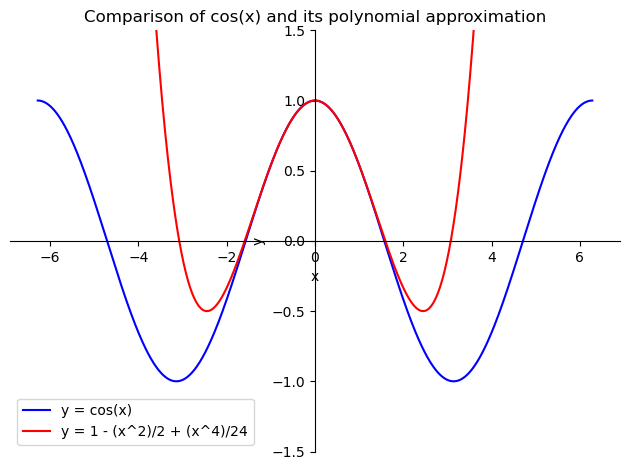

In [42]:
from sympy import symbols, cos, plot
from sympy.plotting import plot as sympy_plot

x = symbols("x")

# The cosine function and its Taylor approximation (up to x^4, since cos(x) is an even function)
y_cos = cos(x)
y_poly = 1 - x**2 / 2 + x**4 / 24 # Taylor expansion for cos(x) near 0

# Plotting
p = plot(
    y_cos, y_poly,
    (x, -2 * 3.1416, 2 * 3.1416),
    ylim = (-1.5, 1.5),
    title = "Comparison of cos(x) and its polynomial approximation",
    xlabel = "x",
    ylabel = "y",
    legend = True,
    show = False,
)

p[0].line_color = "blue"
p[0].label = "y = cos(x)"

p[1].line_color = "red"
p[1].label = "y = 1 - (x^2)/2 + (x^4)/24"

p.show()

The following error may occur. For example, something like this:

```
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[20], line 17
     14 p[1].line_color = "red"
     15 p[1].label = "y = x - x^3/6 + x^5/120"
---> 17 p.show()

File ~\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sympy\plotting\backends\textbackend\text.py:14, in TextBackend.show(self)
     12     return
     13 if len(self._series) != 1:
---> 14     raise ValueError(
     15         'The TextBackend supports only one graph per Plot.')
     16 elif not isinstance(self._series[0], LineOver1DRangeSeries):
     17     raise ValueError(
     18         'The TextBackend supports only expressions over a 1D range')

ValueError: The TextBackend supports only one graph per Plot.
```

The error occurs because this example uses _TextBackend_, which only supports one plot per plot() call. This can happen if SymPy can't find an installed graphics backend, such as **Matplotlib**. The capabilities of this library will be discussed in detail in a future article. For now, to ensure plot() works correctly from SymPy, **Matplotlib** can be installed, for example, using the **pip** package manager:

```shell
python -m pip install matplotlib
```

### Tasks

1. Enter the expression
$$3-5\left(\frac{1}{2}-1\right)+0.3-x+y^2+\frac{x+2}{1+10^{-2}},$$
display it on the screen. Do not simplify the expression.

2. Convert the expression to $\LaTeX$. Display the result in Markdown.

3. Set arbitrary values ​​to the variables $х$ and $у$ and recalculate the expression, display the resulting value on the screen.

4. Simplify the expression
$$\left(\frac{2a}{2a+b}-\frac{4a^2}{4a^2+4ab+b^2}\right)\cdot\left(\frac{2a}{4a^2-b^2}+\frac{1}{b-2a}\right)^{-1}+\frac{8a^2}{2a+b}.$$

5. Expand the parentheses in the expressions
   $\dfrac{\left(x+1\right)^3}{\left(x+2\right)^2},$
   $\sin(x+y).$

6. Given two real numbers $a$, $b$, use symbolic expressions to sequentially calculate:
$$x=\frac{e^{-|a|^{1.2}}+\sin\left(a^4-b\right)}{ab},$$
$$y=\frac{\cos\left(a^4-b\right)+\arctan(a)}{b+x},$$
$$z=\frac{\sqrt{\arctan^2{x}+1}}{\left(1+x^2\right)^\frac{3}{2}}.$$
<br>
Output the result to the console.

7. Define two functions that depend on $x$:
$$y\left(x\right)=\sin\left(x\right),$$
$$y\left(x\right)=x-\frac{x^3}{6}+\frac{x^5}{120}$$.
<br>
Calculate their values ​​at points $x=0$, $x=\dfrac{\pi}{6}$, $x=\dfrac{\pi}{4}$, $x=\dfrac{\pi}{2}$.

8. Plot the graphs of the functions from task 7. Plot the graphs separately and both on the same axes.

9. The equations of two intersecting lines on a plane are given:
$$y=k_1 x+b_1,$$
$$y=k_2 x+b_2.$$
Find the angle between them using the formula
$$\tan(\varphi)=\frac{k_2-k_1}{1+k_1 k_2}.$$
Express $\varphi$ and convert to degrees.

10. Find the solution to the equation:
$$x^3-9x^2+23x-15=0.$$
Substitute the found roots into the equation and verify that the equation is correct.
Check the roots graphically: plot a graph of the left side of the equation.

11. Find the maximum and minimum values ​​of the left side of the equation from task 10 on the interval $[1, 5]$.

12. Solve the equation $x=\cos(x)$.
First graphically, then numerically.

13. Solve the system of two equations
$$\left\{\begin{matrix}
2x+y=3,\\
4x+3y=7.
\end{matrix}\right.$$
Find the roots and check them graphically.

14. Solve the inequality
$$\frac{3(x+4)}{x^2+2}<5+x-x^2.$$

15. Calculate limits
$$\lim_{x\rightarrow\infty}\left(\frac{x^2-x}{x+5}-\frac{x^3+2x}{x^2-3}\right),\quad \lim_{x\rightarrow\infty}\left(1+\frac{x-3}{x^2+4}\right)^{x},\quad \lim_{x\rightarrow 1}\frac{\sin{\pi x}}{\ln{x}}.$$

16. Given an arbitrary function $z$ of two variables $x$ and $y$. Find its derivatives:
- with respect to $x$, with respect to $y$, with respect to $x$ and $y$;
- find any third derivative;
- find a higher-order derivative.

17. Take indefinite integrals
$$\int\frac{\ln x}{x\sqrt{1+\ln x}}dx,\quad \int\frac{dx}{3\sin^2{x}-8\sin{x}\cos{x}+5\cos^2{x}}.$$

18. Take definite integrals
$$\int_{0}^{2\pi}\frac{dx}{(2+\cos x)(3+\cos x)}dx,\quad \int_0^{\infty}\frac{\arctan x}{\left(1+x^2\right)^{\frac{3}{2}}}dx.$$